In [2]:
%load_ext autoreload
%autoreload 2

In [1]:
import numpy as np
from tqdm import tqdm
import matplotlib
import pickle as pi
# from funcs_for_kappa_BHZ import localgap_sys
from funcs_for_kappa_3D import localgap_sys_3D
from load_files_from_cluster import load_cluster_results

import matplotlib.pyplot as plt
import cmasher as csh
import matplotlib.gridspec as gridspec

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

# BHZ model

In [ ]:
kappa_values = np.linspace(0, 25, 50)
E_values = np.linspace(-2.5, 2.5, 50)

Delta_values = np.linspace(-2, 4, 50)
W_values = np.linspace(0, 15, 50)
    
        
        

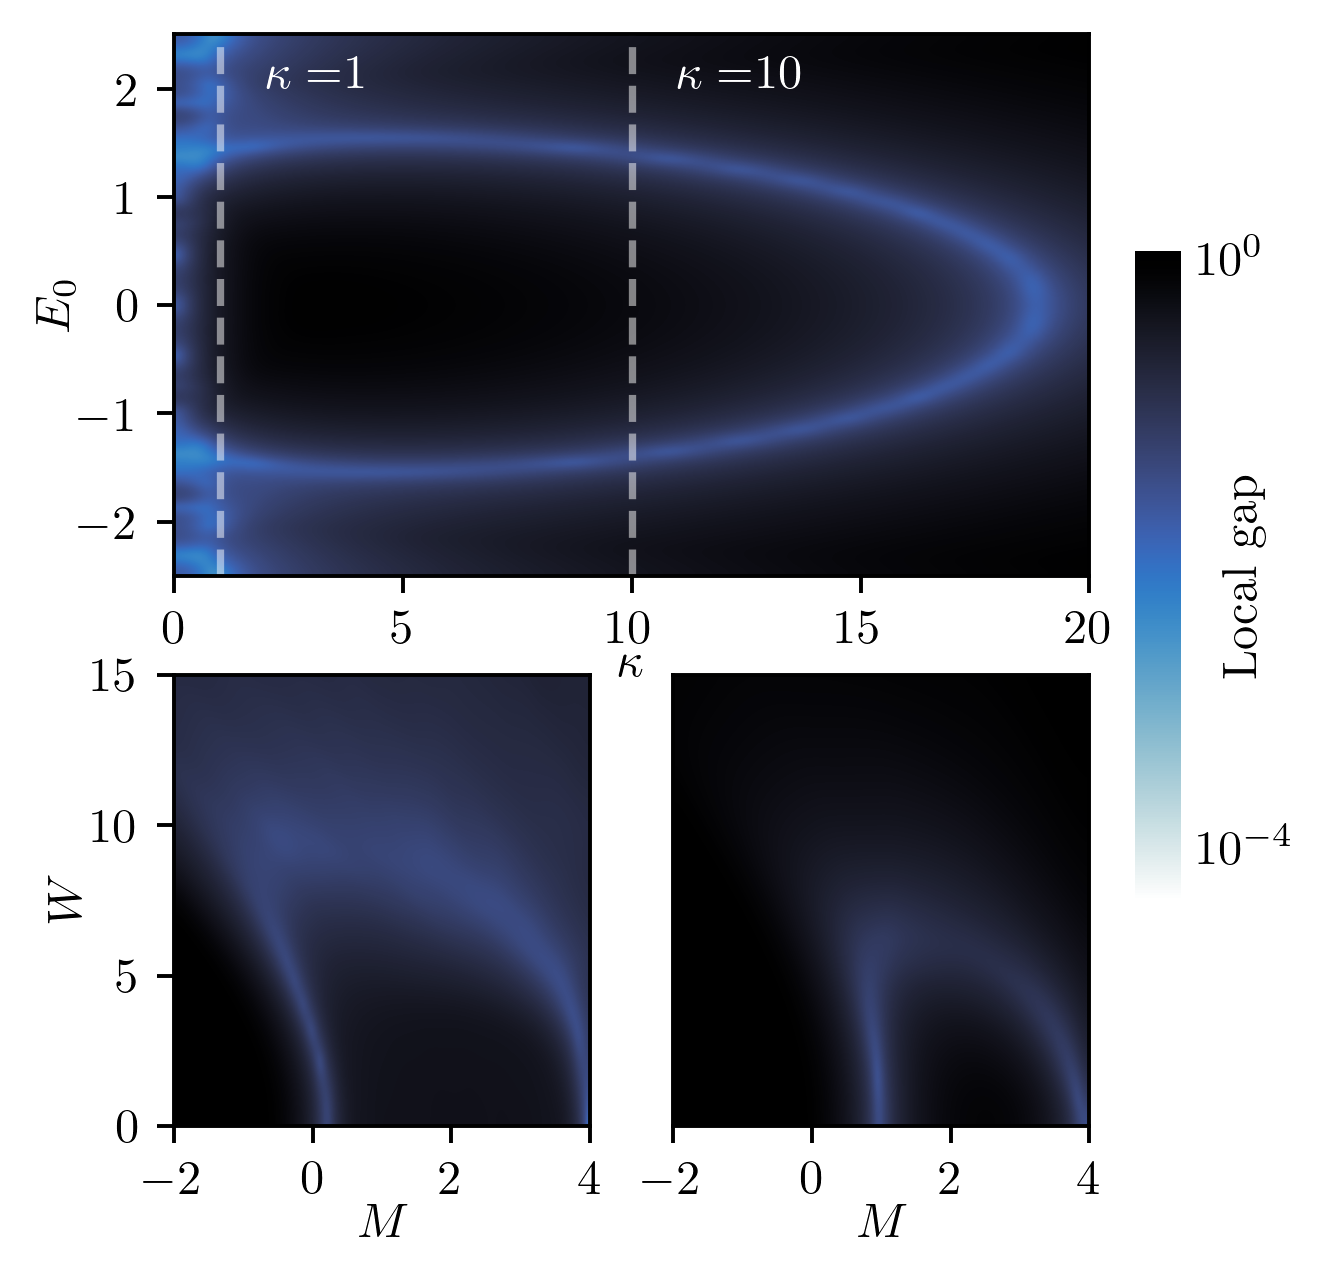

In [14]:
localgap_grid = pi.load(open("data/2D_localgap_kappa_E_grid.pkl", "rb"))
avg_locgap = [
    pi.load(open("data/2D_kappa-1_locgap_Delta_W_grid.pkl", "rb")),
    pi.load(open("data/2D_kappa-10_locgap_Delta_W_grid.pkl", "rb"))
]

fig = plt.figure(figsize=(aps_halfwidth, aps_halfwidth*1.2), dpi=350)
gs = gridspec.GridSpec(
    2, 2,
    height_ratios=[1.2, 1],
    width_ratios=[1, 1], 
    )

ax_top = fig.add_subplot(gs[0, :2])
ax_bl = fig.add_subplot(gs[1, 0])
ax_br = fig.add_subplot(gs[1, 1])


im = ax_top.imshow(
    localgap_grid.T,
    extent=(kappa_values[0], kappa_values[-1], E_values[0], E_values[-1]),
    origin="lower",
    aspect="auto",
    cmap=csh.arctic_r,
    interpolation='bicubic',
    norm='log',
    rasterized=True,
)


for x in [1,10]:
    ax_top.axvline(x=x, color='white', linestyle='--', alpha=0.5)
    ax_top.text(x+1, E_values[-1]-0.5, r'$\kappa=$'+str(x), color='white')

ax_top.set_xlim(0,20)

ax_top.set_xlabel(r'$\kappa$', labelpad=-2)
ax_top.set_ylabel(r'$E_0$', labelpad=0)
# plt.savefig("localgap_kappa_grid.png", bbox_inches='tight')



for i, axes in enumerate([ax_bl, ax_br]):
    axes.imshow(
        avg_locgap[i].T,
        extent=(Delta_values[0], Delta_values[-1], W_values[0], W_values[-1]),
        origin="lower",
        aspect="auto",
        cmap=csh.arctic_r,
        interpolation='bicubic',
        norm='log',
        vmin=10**np.round(np.min(np.log10(localgap_grid[:,:].T))),
        vmax=10**np.floor(np.max(np.log10(localgap_grid[:,:].T))),
        rasterized=True,
    )
    axes.set_xticks([-2, 0, 2, 4])
    axes.set_xlabel(r'$M$', labelpad=0)
    
ax_bl.set_ylabel(r'$W$', labelpad=0)
ax_br.set_yticks([])


ax_cbar = ax_top.inset_axes([1.05, -0.6, 0.05, 1.2])
cbar = fig.colorbar(
    im,
    cax=ax_cbar,
    orientation='vertical',
    fraction=1,
    norm='log',
    # label='Local gap',
    )
cbar.set_label('Local gap', labelpad=-15)
cbar.outline.set_visible(False)
cbar.ax.minorticks_off()     
cbar.ax.tick_params(length=0)      
cbar.set_ticks([10**np.round(np.min(np.log10(localgap_grid[:,:].T))), 10**np.floor(np.max(np.log10(localgap_grid[:,:].T)))])


ax_cbar.tick_params(length=0)
ax_cbar.set_frame_on(False)
ax_cbar.set_rasterized(True)
# cbar.outline.set_visible(False)

label = ['a)', 'b)', 'c)']
# for axes in [ax_top, ax_bl, ax_br]:
#     axes.text(label.pop(0), transform=axes.transAxes, xy=(0.05, 0.9), color='white', y=0.9, s=axes.texts[0].get_text(), fontsize=12)

In [ ]:
fig.savefig("localgap_kappa_grid.pdf", bbox_inches='tight', dpi=350)


# 3D model

In [4]:
output_a = load_cluster_results(
    "results_3d_a",
    "results_kappa*_E0_50_L10_M_2.h5",
)
output_b = load_cluster_results(
    "results_3d_bc",
    "results_seed*_kappa_2_L10.h5",
    check_reals=50,
)
output_c = load_cluster_results(
    "results_3d_bc",
    "results_seed*_kappa_10_L10.h5",
    check_reals=50,
)

Loaded 50 files from results_3d_a
kappa range: [0.000,20.000]
Parameters for the calculation:
  A: 1
  Emax: 2.5
  Emin: -2.5
  MJ: 2
  beta: 1
  bond_lengthscale: 0.1
  bond_power: 0.1
  kappa: 0.0
  kappa_shift: 0
  num_reals: 50
  onsite_disorder: 0
  par_variable_name: kappa
  resolution: 10
  seed: 0
  system_size: 10
Outputs obtained from the calculation: ['local_gap']
Loaded 100 files from results_3d_bc
seed range: [0.000,99.000]
Parameters for the calculation:
  A: 1
  Mmax: 4.0
  Mmin: 0.0
  Wmax: 10.0
  Wmin: 0.0
  beta: 1
  bond_lengthscale: 0.1
  bond_power: 0.1
  kappa: 2
  kappa_shift: 0
  par_variable_name: seed
  resolution: 10
  seed: 0
  system_size: 10
Outputs obtained from the calculation: ['local_gap_grid']
Loaded 100 files from results_3d_bc
seed range: [0.000,99.000]
Parameters for the calculation:
  A: 1
  Mmax: 4.0
  Mmin: 0.0
  Wmax: 10.0
  Wmin: 0.0
  beta: 1
  bond_lengthscale: 0.1
  bond_power: 0.1
  kappa: 10
  kappa_shift: 0
  par_variable_name: seed
  re

In [10]:
localgap_grid = np.array(output_a['local_gap'])
localgap_b = np.mean([elem for elem in output_b['local_gap_grid']], axis = 0)
localgap_c = np.mean([elem for elem in output_c['local_gap_grid']], axis = 0)

all = np.array([localgap_grid, localgap_b, localgap_c])
vmin = 10**np.round(np.min(np.log10(all)))
vmax = 10**np.floor(np.max(np.log10(all)))

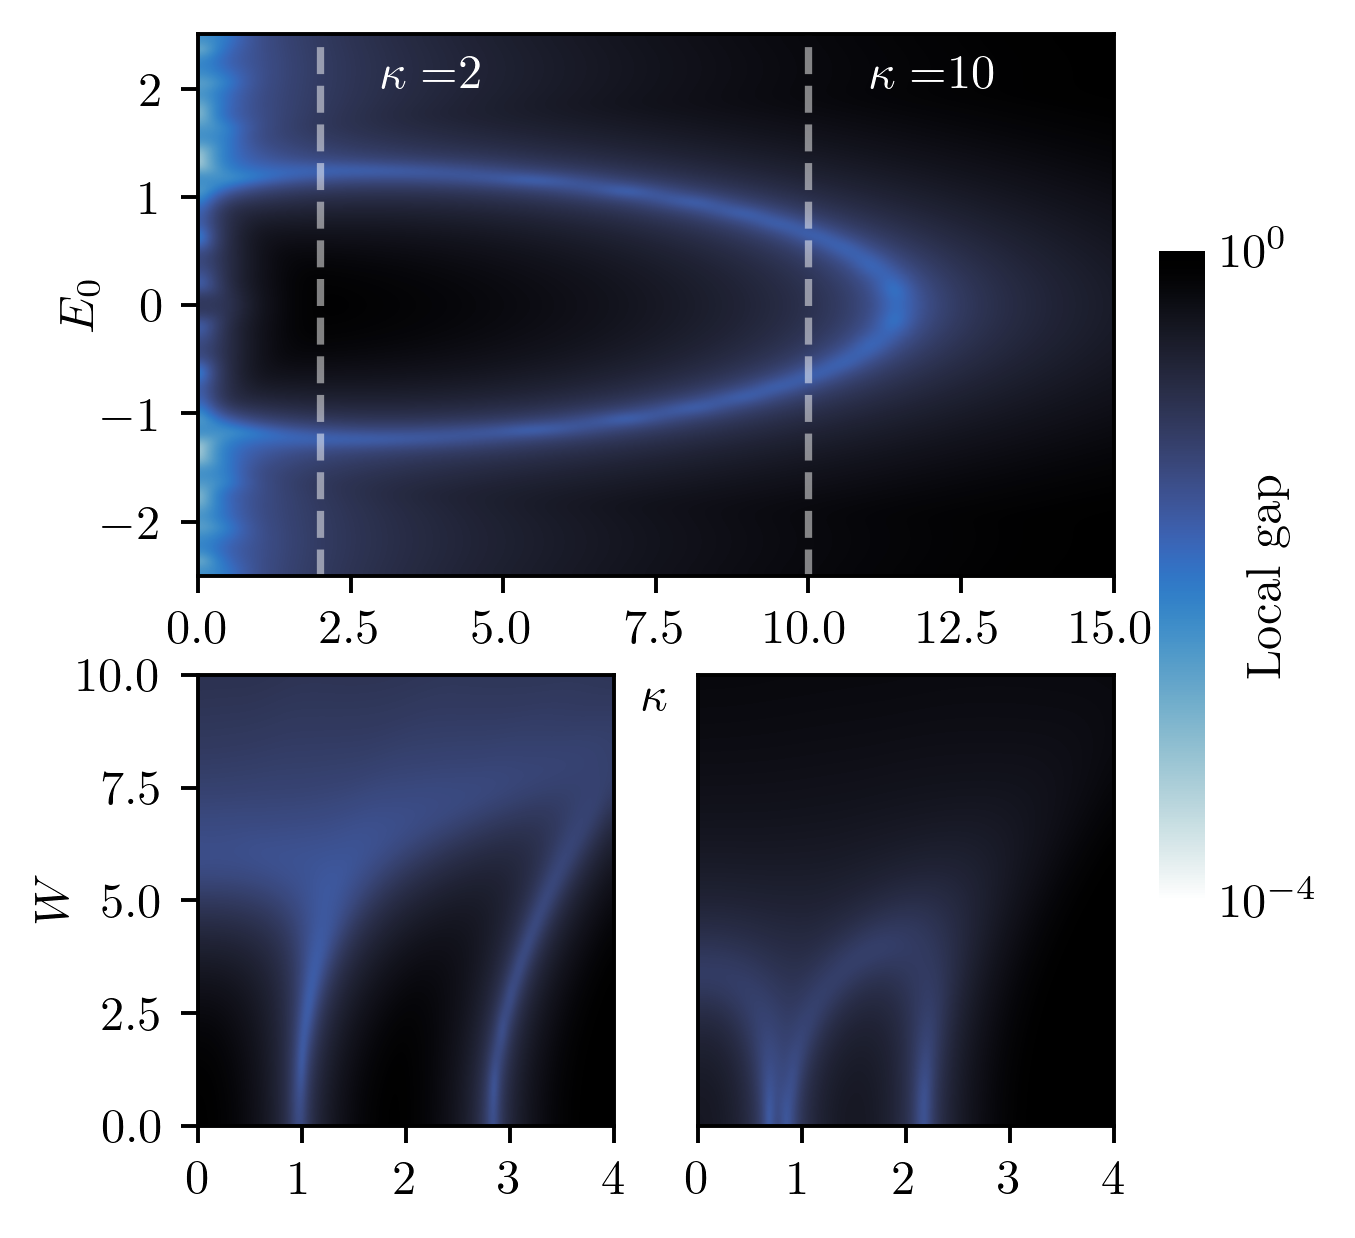

In [22]:
M_values = np.linspace(0, 4, 50)
kappa_values = np.linspace(0, 20, 50)
E_values = np.linspace(-2.5, 2.5, 50)



fig = plt.figure(figsize=(aps_halfwidth, aps_halfwidth*1.2), dpi=350)
gs = gridspec.GridSpec(
    2, 2,
    height_ratios=[1.2, 1],
    width_ratios=[1, 1], 
    )

ax_top = fig.add_subplot(gs[0, :2])
ax_bl = fig.add_subplot(gs[1, 0])
ax_br = fig.add_subplot(gs[1, 1])


im = ax_top.imshow(
    localgap_grid.T,
    extent=(kappa_values[0], kappa_values[-1], E_values[0], E_values[-1]),
    origin="lower",
    aspect="auto",
    cmap=csh.arctic_r,
    interpolation='bicubic',
    norm='log',
    rasterized=True,
    vmin=vmin,
    vmax=vmax,
)

ax_top.set_xlim(0,15)

# colorbar

for x in [2,10]:
    ax_top.axvline(x=x, color='white', linestyle='--', alpha=0.5)
    ax_top.text(x+1, E_values[-1]-0.5, r'$\kappa=$'+str(x), color='white')

# ax_top.set_xlim(0,20)

ax_top.set_xlabel(r'$\kappa$', labelpad=5)
ax_top.set_ylabel(r'$E_0$', labelpad=0)
# # plt.savefig("localgap_kappa_grid.png", bbox_inches='tight')


M_values = np.linspace(0, 4, 50)
W_values = np.linspace(0, 10, 50)

# for i, axes in enumerate([ax_bl, ax_br]):
im = ax_bl.imshow(
    localgap_b.T,
    extent=(M_values[0], M_values[-1], W_values[0], W_values[-1]),
    origin="lower",
    aspect="auto",
    cmap=csh.arctic_r,
    interpolation='bicubic',
    norm='log',
    rasterized=True,
    vmin=vmin,
    vmax=vmax,
)
ax_br.imshow(
    localgap_c.T,
    extent=(M_values[0], M_values[-1], W_values[0], W_values[-1]),
    origin="lower",
    aspect="auto",
    cmap=csh.arctic_r,
    interpolation='bicubic',
    norm='log',
    rasterized=True,
    vmin=vmin,
    vmax=vmax,
)
ax_bl.set_ylabel(r'$W$', labelpad=0)
ax_bl.set_xticks([0,1,2,3,4])
ax_br.set_xticks([0,1,2,3,4])
ax_br.set_yticks([])


ax_cbar = ax_top.inset_axes([1.05, -0.6, 0.05, 1.2])
cbar = fig.colorbar(
    im,
    cax=ax_cbar,
    orientation='vertical',
    fraction=1,
    norm='log',
    # label='Local gap',
    )
cbar.set_label('Local gap', labelpad=-15)
cbar.outline.set_visible(False)
cbar.ax.minorticks_off()     
cbar.ax.tick_params(length=0)      
cbar.set_ticks([vmin, vmax])


ax_cbar.tick_params(length=0)
ax_cbar.set_frame_on(False)
ax_cbar.set_rasterized(True)
# # cbar.outline.set_visible(False)

label = ['a)', 'b)', 'c)']
# for axes in [ax_top, ax_bl, ax_br]:
#     axes.text(label.pop(0), transform=axes.transAxes, xy=(0.05, 0.9), color='white', y=0.9, s=axes.texts[0].get_text(), fontsize=12)